In [101]:
#exp_save_path = r'C:\Users\rehan\meine_Repos\Masterarbeit\Paper\results\(n_train)1000__(B_RF)1000__(B_1)200__(n_sim)1000__(seed)42__4kovariates\121.90058'
exp_save_path = r'C:\Users\rehan\meine_Repos\Masterarbeit\Paper\results\(n_train)1000__(B_RF)1000__(B_1)200__(n_sim)1000__(seed)42__4kovariates_higherS(tau)\109.90058'

collage_name = 'figure4_morris_high_S.png'

xlim1 =  [-999 , 0.05]
xlim2 =  [-999 , 0.05]
xlim3 = [-999 , 0.05]

#### setting

In [102]:
import pandas as pd
import json
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import os

# erstelle verzeichnis, falls nicht vorhanden /help_figures
if not os.path.exists('help_figures'):
    os.makedirs('help_figures')

with open(exp_save_path + '/setting.json') as f:
    exp_settings = json.load(f)
S_t = exp_settings["true_survival_probability[1,3,5]"]

# lade results
results1 = pd.read_csv(exp_save_path + f"/results1__(zero_weights){exp_settings['portion_zero_weights_train[1,3,5]'][0]}__(seen_events){exp_settings['portion_seen_events_train[1,3,5]'][0]}.csv")
results3 = pd.read_csv(exp_save_path + f"/results3__(zero_weights){exp_settings['portion_zero_weights_train[1,3,5]'][1]}__(seen_events){exp_settings['portion_seen_events_train[1,3,5]'][1]}.csv")
results5 = pd.read_csv(exp_save_path + f"/results5__(zero_weights){exp_settings['portion_zero_weights_train[1,3,5]'][2]}__(seen_events){exp_settings['portion_seen_events_train[1,3,5]'][2]}.csv")
x_pred = exp_settings['X_pred_point']

#### plot corrs

<Figure size 1000x1000 with 0 Axes>

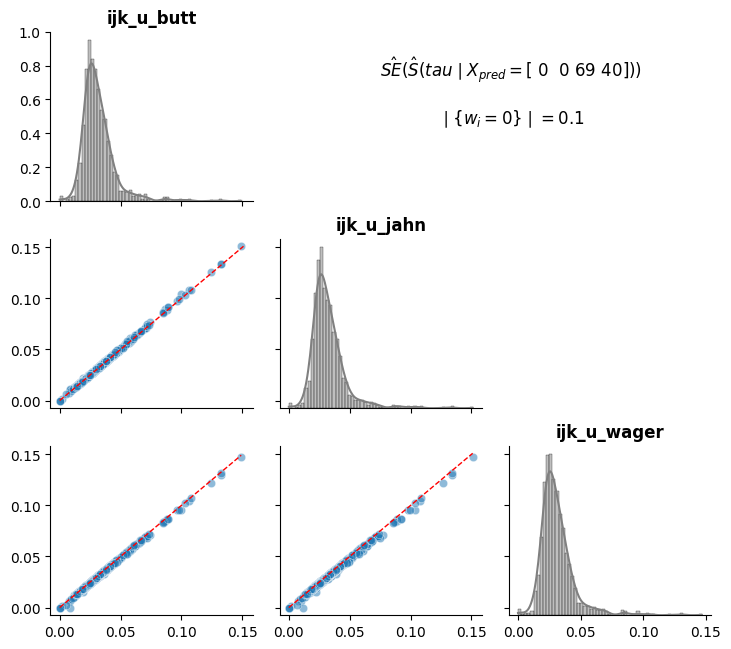

<Figure size 1000x1000 with 0 Axes>

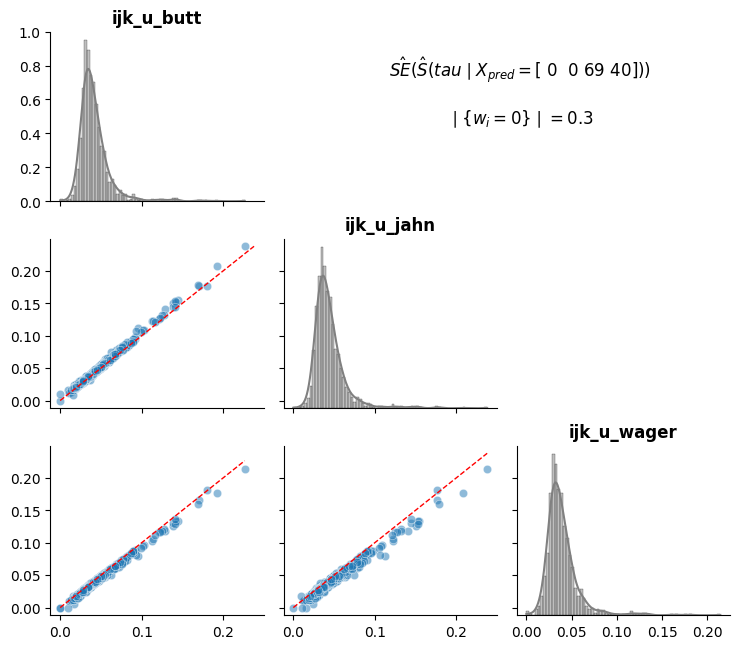

<Figure size 1000x1000 with 0 Axes>

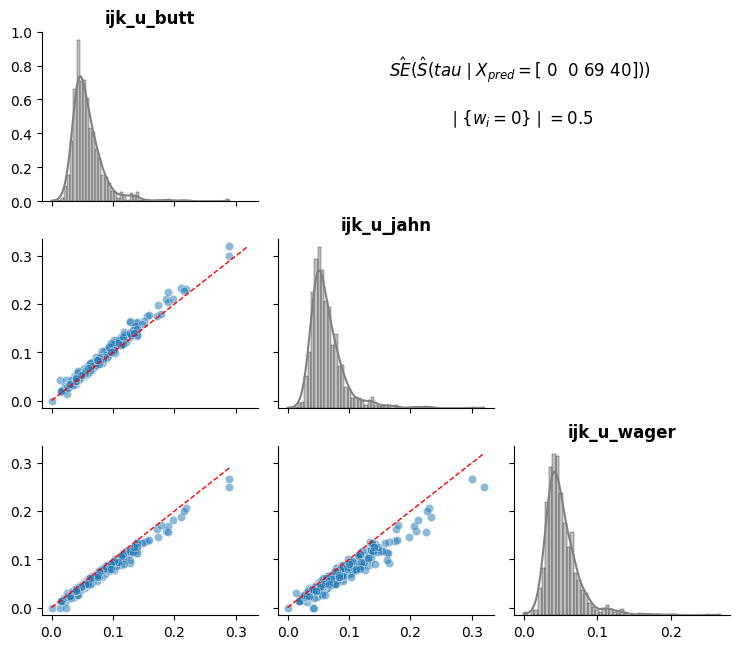

In [103]:
def plot_corr(results1, prop_weights, x_pred):
    ijk_u_butt  = results1['ijk_u_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)
    ijk_u_jahn = results1['ijk_u_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)
    ijk_u_wager  = results1['ijk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)

    df = pd.DataFrame({'ijk_u_butt':   ijk_u_butt, 'ijk_u_jahn':   ijk_u_jahn, 'ijk_u_wager': ijk_u_wager})

    # Bildgröße einstellen
    plt.figure(figsize=(10, 10))  # Ändere (12, 12) auf die gewünschte Breite und Höhe

    # PairGrid aufsetzen
    g = sns.PairGrid(df, diag_sharey=False)
    g.map_lower(sns.scatterplot, alpha=0.5)

    # Linie x = y
    def plot_line_x_equals_y(x, y, **kwargs):
        ax = plt.gca()
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], 
                color='red', linestyle='--', linewidth=1)
    g.map_lower(plot_line_x_equals_y)

    # Hauptdiagonale: Histogramm
    g.map_diag(sns.histplot, kde=True, color="gray")

    # Obere Dreiecksplots ausblenden
    for i, j in zip(*np.triu_indices_from(g.axes, 1)):
        g.axes[i, j].set_visible(False)

    # X-Label-Namen über den obersten Plots platzieren
    for i, colname in enumerate(df.columns):
        for j in range(len(df.columns)):
            if i == j:
                ax = g.axes[j, i]  # Zugriff auf die oberste Zeile
                ax.set_title(colname, fontsize=12, fontweight='bold')  # Titel über Plot
    for ax_row in g.axes:
        for ax in ax_row:
            ax.set_xlabel("")
            ax.set_ylabel("")
    # Gesamttitel
    g.fig.suptitle(r"$\hat{SE}(\hat{S}(tau\mid X_{pred}=$"+x_pred+'))\n\n'+r"$\mid \{w_i = 0\} \mid =$"+str(prop_weights/10), x=0.7, y=0.8)
    plt.tight_layout()
    plt.savefig("./help_figures/corr"+str(prop_weights)+".png", dpi=300)

plot_corr(results1, 1, x_pred)
plot_corr(results3, 3, x_pred)
plot_corr(results5, 5, x_pred)


#### plot comparisons

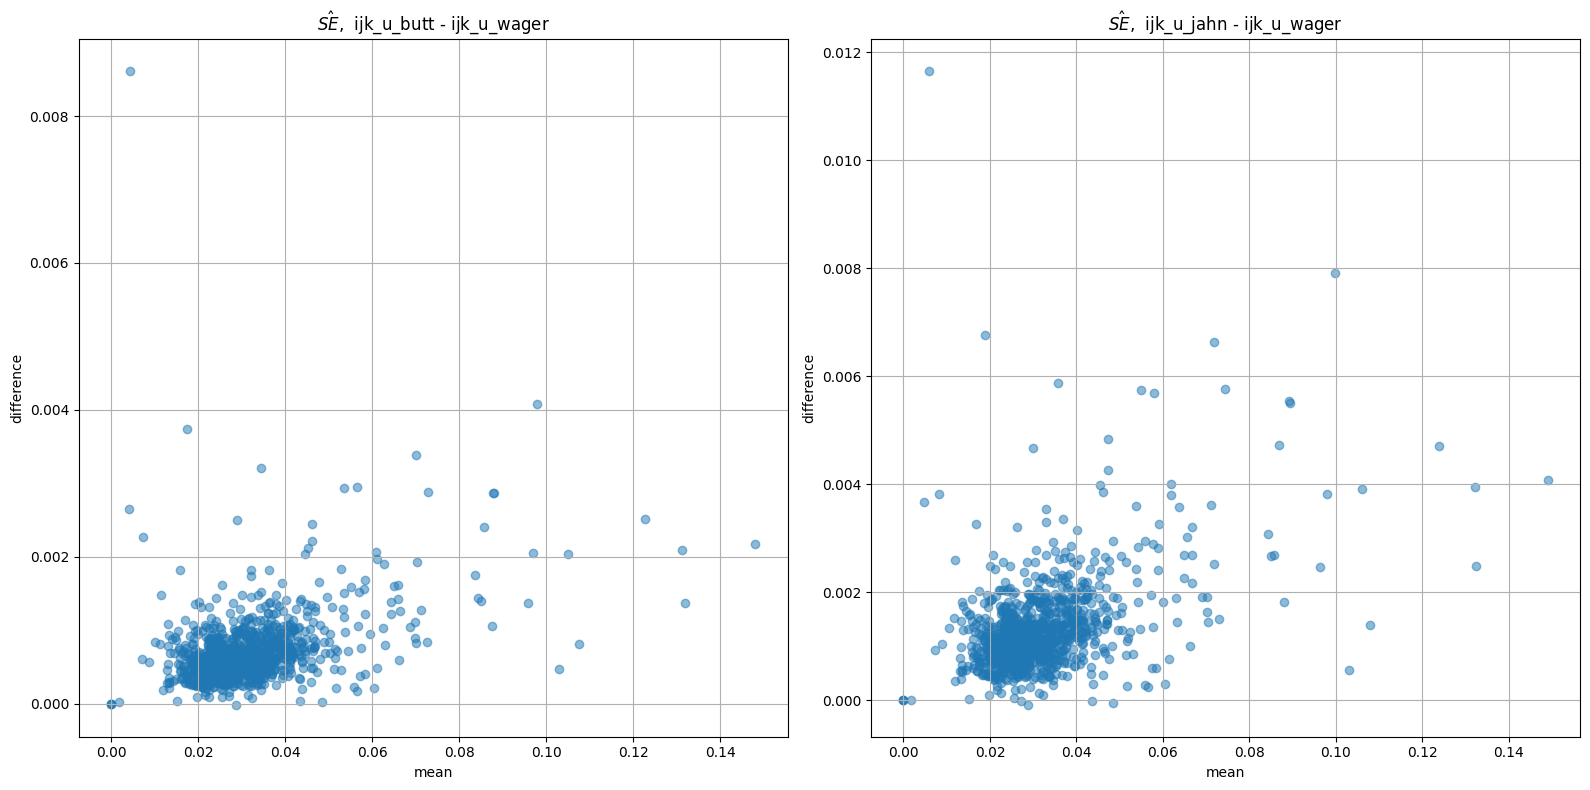

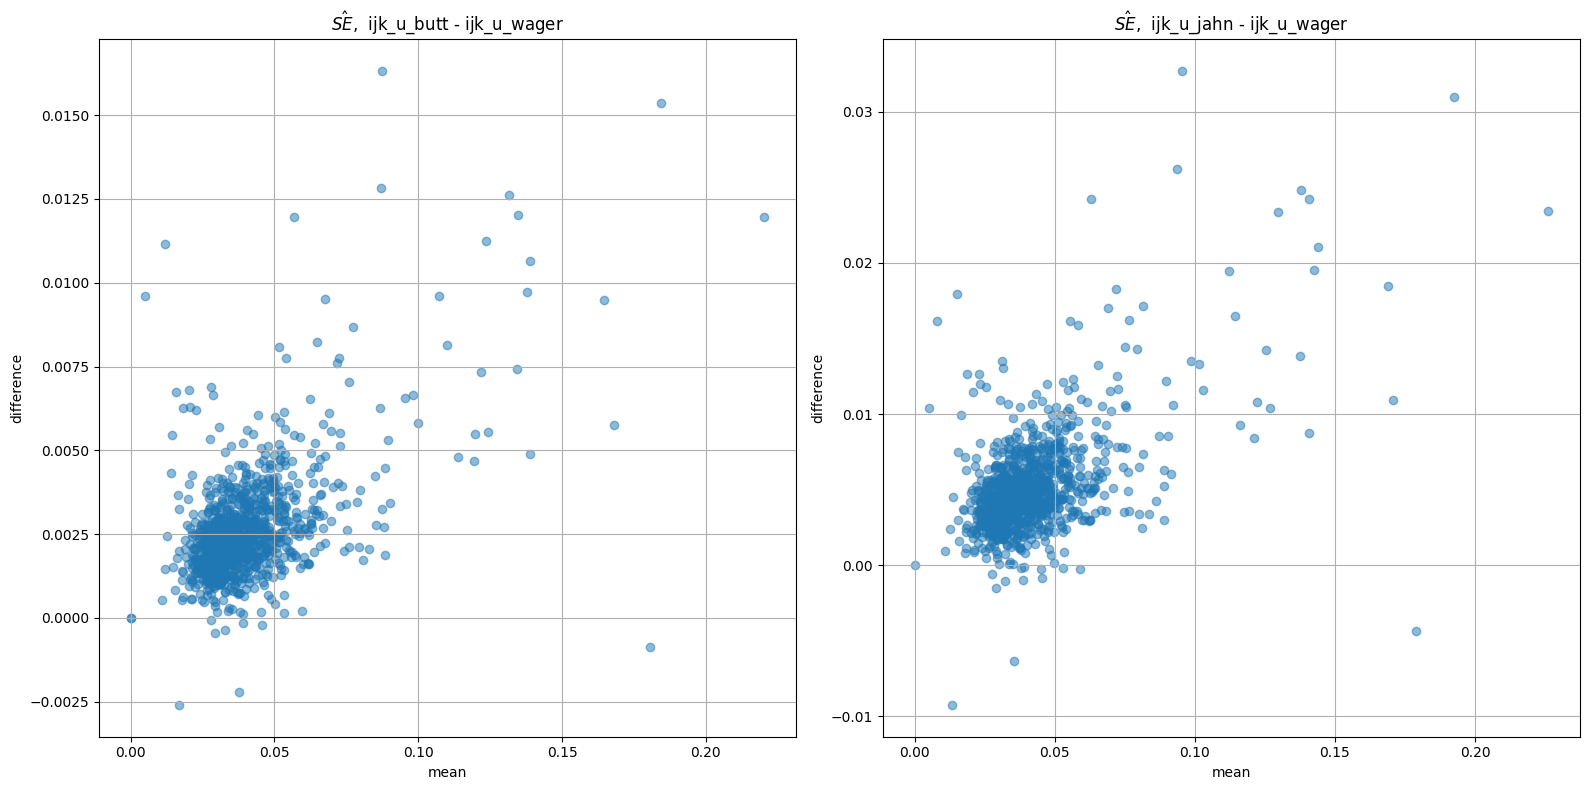

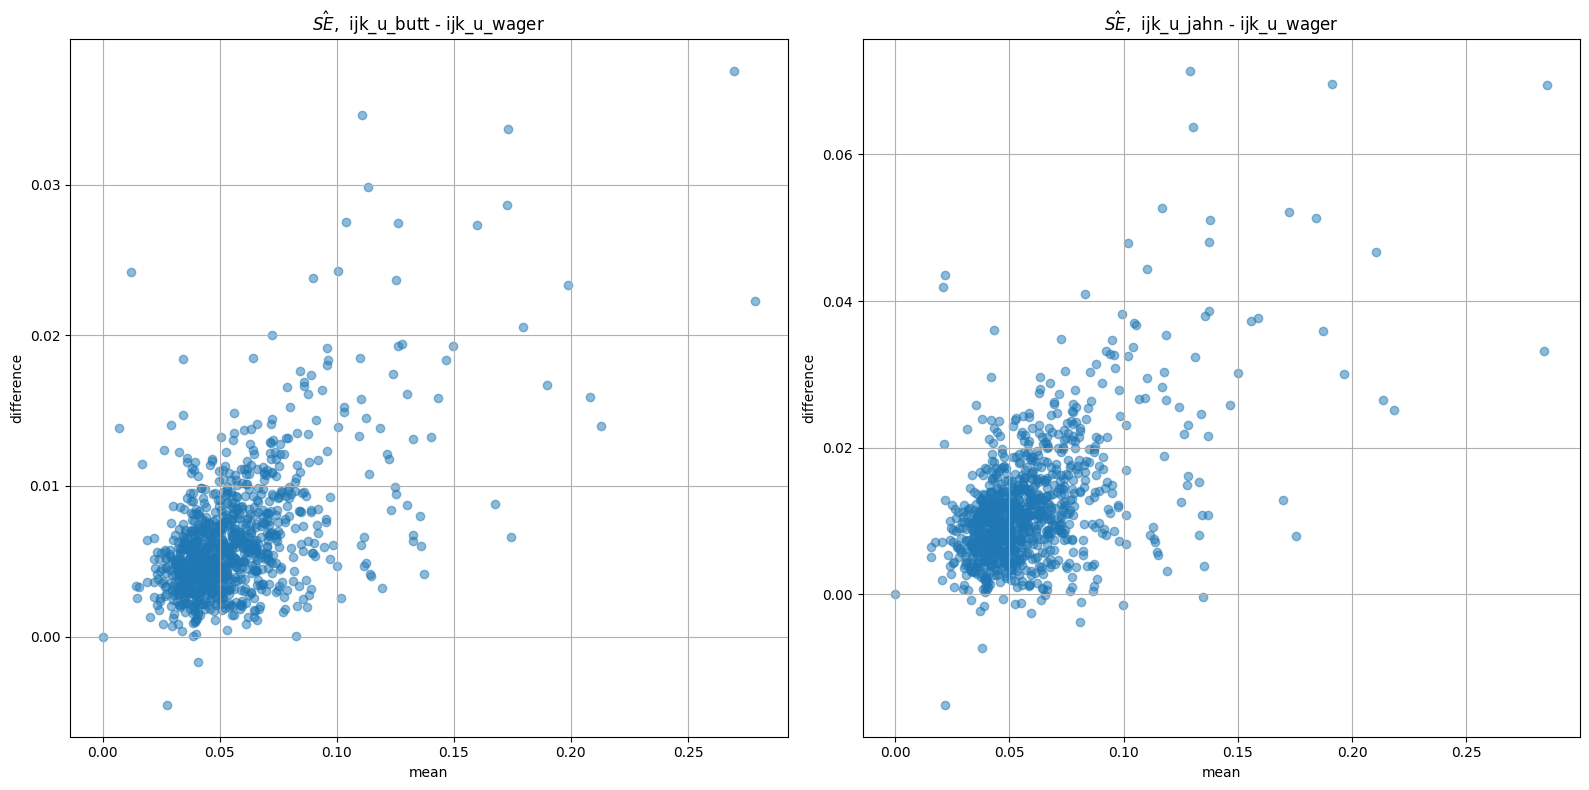

In [104]:
def plot_diff(results1, prop_weights,xlim1):    
    # erstelle ein 4x4 grid für 4 verschiedene plots die ich nachher einfügen werde
    fig, axs = plt.subplots(1, 2, figsize=(16,8 ))

    # u_butt -   u_wager
    means = (results1['ijk_u_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) + results1['ijk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)) / 2
    differences = results1['ijk_u_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - results1['ijk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)
    axs[0].scatter(means, differences, alpha=0.5)
    #axs[0].set_xlim(xlim1)
    axs[0].set_title(r'$\hat{SE}$,  ijk_u_butt - ijk_u_wager')
    axs[0].set_xlabel('mean')
    axs[0].set_ylabel('difference')
    axs[0].grid(True)

    # u_jahn -   u_wager
    means = (results1['ijk_u_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) + results1['ijk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0))/2
    differences = results1['ijk_u_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - results1['ijk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)
    axs[1].scatter(means, differences, alpha=0.5)
    #axs[1].set_xlim(xlim1)
    axs[1].set_title(r'$\hat{SE}$,  ijk_u_jahn - ijk_u_wager')
    axs[1].set_ylabel('difference')
    axs[1].set_xlabel('mean')
    axs[1].grid(True)

    plt.tight_layout()
    plt.savefig("./help_figures/diff"+str(prop_weights)+".png", dpi=300)
plot_diff(results1, 1,xlim3)
plot_diff(results3, 3,xlim3)
plot_diff(results5, 5,xlim3)

#### erstelle figure 4 morris

In [105]:
import os
from PIL import Image

# Pfad zum Ordner mit den Bildern
pp = r'C:\\Users\\rehan\\meine_Repos\\Masterarbeit\\Paper\\help_figures'

image_files = [
    "corr1.png", "diff1.png",
    "corr3.png", "diff3.png",
    "corr5.png", "diff5.png"
]

# Lade die Bilder
images = [Image.open(os.path.join(pp, f)) for f in image_files]

# Prüfe, ob alle Bilder erfolgreich geladen wurden
if len(images) != 6:
    raise ValueError("Es konnten nicht alle 6 Bilder geladen werden. Überprüfe die Dateinamen und den Pfad.")

# Ermittle die maximale Breite und Höhe der Bilder
widths, heights = zip(*(img.size for img in images))
max_width = max(widths)
max_height = max(heights)

# Neues Bild mit 2 Spalten und 3 Zeilen erstellen
new_width = 2 * max_width
new_height = 3 * max_height
new_img = Image.new("RGB", (8_000, new_height), "white")  # Hintergrund auf weiß setzen

# Positionen für die 6 Bilder
positions = [
    (0, 0), (3000, 0),           # Erste Zeile: preds1, vars1
    (0, max_height), (3000, max_height),  # Zweite Zeile: preds3, vars3
    (0, 2 * max_height), (3000, 2 * max_height)  # Dritte Zeile: preds5, vars5
]

# Bilder einfügen
for pos, img in zip(positions, images):
    new_img.paste(img, pos)

# Speichere das Ergebnis
output_path = os.path.join(pp, collage_name)
new_img.save(output_path)
print(f"Collage wurde erfolgreich unter {output_path} gespeichert.")

# lösch die image files 
for f in image_files:
    os.remove(os.path.join(pp, f))

Collage wurde erfolgreich unter C:\\Users\\rehan\\meine_Repos\\Masterarbeit\\Paper\\help_figures\figure4_morris_high_S.png gespeichert.
